# Statistics & Probability Assignment


In [ ]:
from io import StringIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, zscore
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

csv_data = '''Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
E001,AI,Male,24,2,45000,4,5,18,120000,4.6,Hybrid,No,Spam,Positive,120,Yes,42,0.10
E002,HR,Female,29,5,58000,5,7,25,150000,4.8,Office,No,Not Spam,Positive,180,Yes,48,0.05
E003,Finance,Male,35,10,85000,3,6,12,90000,4.1,Office,Yes,Spam,Negative,95,No,30,0.80
E004,Testing,Female,26,3,50000,4,4,15,110000,4.3,Remote,No,Not Spam,Neutral,140,Yes,39,0.12
E005,AI,Male,31,7,72000,5,9,30,175000,4.9,Hybrid,No,Spam,Positive,220,Yes,55,0.07
E006,HR,Female,27,4,54000,3,5,10,98000,4.0,Office,Yes,Not Spam,Negative,88,No,28,0.75
E007,Finance,Male,41,15,120000,5,11,35,210000,4.9,Hybrid,No,Spam,Positive,260,Yes,61,0.03
E008,Testing,Female,23,1,39000,2,3,8,72000,3.8,Remote,Yes,Spam,Negative,70,No,20,0.90
E009,AI,Female,30,6,68000,4,8,22,165000,4.7,Hybrid,No,Not Spam,Positive,205,Yes,50,0.08
E010,Finance,Male,38,12,98000,5,10,28,198000,4.8,Office,No,Spam,Positive,245,Yes,58,0.04
E011,HR,Male,33,8,76000,4,6,20,132000,4.5,Office,No,Spam,Neutral,170,Yes,45,0.15
E012,Testing,Female,28,5,61000,3,5,14,101000,4.2,Remote,Yes,Not Spam,Negative,110,No,31,0.65
E013,AI,Male,36,11,105000,5,12,38,230000,5.0,Hybrid,No,Spam,Positive,290,Yes,65,0.02
E014,Finance,Female,32,7,79000,4,8,24,176000,4.6,Office,No,Not Spam,Positive,215,Yes,53,0.06
E015,Testing,Male,25,2,43000,3,4,11,85000,3.9,Remote,Yes,Spam,Negative,82,No,25,0.88
E016,AI,Female,40,14,125000,5,13,40,250000,5.0,Hybrid,No,Spam,Positive,310,Yes,68,0.01
E017,HR,Female,37,9,83000,4,7,21,142000,4.4,Office,No,Not Spam,Positive,195,Yes,49,0.09
E018,Finance,Male,34,9,87000,4,9,23,184000,4.7,Hybrid,No,Spam,Positive,225,Yes,56,0.05
E019,Testing,Female,29,4,56000,3,5,16,104000,4.1,Remote,Yes,Not Spam,Neutral,118,No,34,0.60
E020,AI,Male,45,18,150000,5,15,45,300000,5.0,Hybrid,No,Spam,Positive,360,Yes,72,0.01'''
df=pd.read_csv((csv_data))
df


,Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
0,E001,AI,Male,24,2,45000,4,5,18,120000,4.6,Hybrid,No,Spam,Positive,120,Yes,42,0.10
1,E002,HR,Female,29,5,58000,5,7,25,150000,4.8,Office,No,Not Spam,Positive,180,Yes,48,0.05
2,E003,Finance,Male,35,10,85000,3,6,12,90000,4.1,Office,Yes,Spam,Negative,95,No,30,0.80
3,E004,Testing,Female,26,3,50000,4,4,15,110000,4.3,Remote,No,Not Spam,Neutral,140,Yes,39,0.12
4,E005,AI,Male,31,7,72000,5,9,30,175000,4.9,Hybrid,No,Spam,Positive,220,Yes,55,0.07
5,E006,HR,Female,27,4,54000,3,5,10,98000,4.0,Office,Yes,Not Spam,Negative,88,No,28,0.75
6,E007,Finance,Male,41,15,120000,5,11,35,210000,4.9,Hybrid,No,Spam,Positive,260,Yes,61,0.03
7,E008,Testing,Female,23,1,39000,2,3,8,72000,3.8,Remote,Yes,Spam,Negative,70,No,20,0.90
8,E009,AI,Female,30,6,68000,4,8,22,165000,4.7,Hybrid,No,Not Spam,Positive,205,Yes,50,0.08
9,E010,Finance,Male,38,12,98000,5,10,28,198000,4.8,Office,No,Spam,Positive,245,Yes,58,0.04


## Q1

In [3]:
df

,Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
0,E001,AI,Male,24,2,45000,4,5,18,120000,4.6,Hybrid,No,Spam,Positive,120,Yes,42,0.10
1,E002,HR,Female,29,5,58000,5,7,25,150000,4.8,Office,No,Not Spam,Positive,180,Yes,48,0.05
2,E003,Finance,Male,35,10,85000,3,6,12,90000,4.1,Office,Yes,Spam,Negative,95,No,30,0.80
3,E004,Testing,Female,26,3,50000,4,4,15,110000,4.3,Remote,No,Not Spam,Neutral,140,Yes,39,0.12
4,E005,AI,Male,31,7,72000,5,9,30,175000,4.9,Hybrid,No,Spam,Positive,220,Yes,55,0.07
5,E006,HR,Female,27,4,54000,3,5,10,98000,4.0,Office,Yes,Not Spam,Negative,88,No,28,0.75
6,E007,Finance,Male,41,15,120000,5,11,35,210000,4.9,Hybrid,No,Spam,Positive,260,Yes,61,0.03
7,E008,Testing,Female,23,1,39000,2,3,8,72000,3.8,Remote,Yes,Spam,Negative,70,No,20,0.90
8,E009,AI,Female,30,6,68000,4,8,22,165000,4.7,Hybrid,No,Not Spam,Positive,205,Yes,50,0.08
9,E010,Finance,Male,38,12,98000,5,10,28,198000,4.8,Office,No,Spam,Positive,245,Yes,58,0.04


## Q2

In [4]:
df.head(10)

,Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
0,E001,AI,Male,24,2,45000,4,5,18,120000,4.6,Hybrid,No,Spam,Positive,120,Yes,42,0.10
1,E002,HR,Female,29,5,58000,5,7,25,150000,4.8,Office,No,Not Spam,Positive,180,Yes,48,0.05
2,E003,Finance,Male,35,10,85000,3,6,12,90000,4.1,Office,Yes,Spam,Negative,95,No,30,0.80
3,E004,Testing,Female,26,3,50000,4,4,15,110000,4.3,Remote,No,Not Spam,Neutral,140,Yes,39,0.12
4,E005,AI,Male,31,7,72000,5,9,30,175000,4.9,Hybrid,No,Spam,Positive,220,Yes,55,0.07
5,E006,HR,Female,27,4,54000,3,5,10,98000,4.0,Office,Yes,Not Spam,Negative,88,No,28,0.75
6,E007,Finance,Male,41,15,120000,5,11,35,210000,4.9,Hybrid,No,Spam,Positive,260,Yes,61,0.03
7,E008,Testing,Female,23,1,39000,2,3,8,72000,3.8,Remote,Yes,Spam,Negative,70,No,20,0.90
8,E009,AI,Female,30,6,68000,4,8,22,165000,4.7,Hybrid,No,Not Spam,Positive,205,Yes,50,0.08
9,E010,Finance,Male,38,12,98000,5,10,28,198000,4.8,Office,No,Spam,Positive,245,Yes,58,0.04


## Q3

In [5]:
df.tail(5)

,Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
15,E016,AI,Female,40,14,125000,5,13,40,250000,5.0,Hybrid,No,Spam,Positive,310,Yes,68,0.01
16,E017,HR,Female,37,9,83000,4,7,21,142000,4.4,Office,No,Not Spam,Positive,195,Yes,49,0.09
17,E018,Finance,Male,34,9,87000,4,9,23,184000,4.7,Hybrid,No,Spam,Positive,225,Yes,56,0.05
18,E019,Testing,Female,29,4,56000,3,5,16,104000,4.1,Remote,Yes,Not Spam,Neutral,118,No,34,0.60
19,E020,AI,Male,45,18,150000,5,15,45,300000,5.0,Hybrid,No,Spam,Positive,360,Yes,72,0.01


## Q4

In [6]:
df.shape

(20, 19)

## Q5

In [7]:
df.dtypes

Employee_ID               str
Department                str
Gender                    str
Age                     int64
Experience              int64
Salary                  int64
Performance_Rating      int64
Projects_Completed      int64
Training_Hours          int64
Monthly_Sales           int64
Customer_Rating       float64
Work_Mode                 str
Left_Company              str
Email_Type                str
Sentiment                 str
Website_Visits          int64
Converted                 str
Monthly_Watch_Time      int64
Fraud_Score           float64
dtype: object

## Q6

In [13]:
qual=df.select_dtypes('object').columns
quant=df.select_dtypes(exclude='object').columns
print('Qualitative:',list(qual))
print('Quantitative:',list(quant))

Qualitative: ['Employee_ID', 'Department', 'Gender', 'Work_Mode', 'Left_Company', 'Email_Type', 'Sentiment', 'Converted']
Quantitative: ['Age', 'Experience', 'Salary', 'Performance_Rating', 'Projects_Completed', 'Training_Hours', 'Monthly_Sales', 'Customer_Rating', 'Website_Visits', 'Monthly_Watch_Time', 'Fraud_Score']


C:\Users\dell\AppData\Local\Temp\ipykernel_30152\2092919368.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qual=df.select_dtypes('object').columns


## Q7

In [14]:
print('Nominal:',list(df.select_dtypes('object').columns))
print('Ratio:',list(df.select_dtypes(exclude='object').columns))

Nominal: ['Employee_ID', 'Department', 'Gender', 'Work_Mode', 'Left_Company', 'Email_Type', 'Sentiment', 'Converted']
Ratio: ['Age', 'Experience', 'Salary', 'Performance_Rating', 'Projects_Completed', 'Training_Hours', 'Monthly_Sales', 'Customer_Rating', 'Website_Visits', 'Monthly_Watch_Time', 'Fraud_Score']


C:\Users\dell\AppData\Local\Temp\ipykernel_30152\2490164885.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print('Nominal:',list(df.select_dtypes('object').columns))


## Q8

In [ ]:
df['Department'].value_counts()

## Q9

In [ ]:
df['Gender'].value_counts()

## Q10

In [ ]:
df['Sentiment'].value_counts()

## Q11

In [ ]:
df['Salary'].mean()

## Q12

In [ ]:
df['Salary'].median()

## Q13

In [ ]:
df['Work_Mode'].mode()[0]

## Q14

In [ ]:
df['Salary'].max()-df['Salary'].min()

## Q15

In [ ]:
df['Salary'].var()

## Q16

In [ ]:
df['Salary'].std()

## Q17

In [ ]:
df['Monthly_Sales'].agg(['min','max'])

## Q18

In [ ]:
df['Customer_Rating'].mean()

## Q19

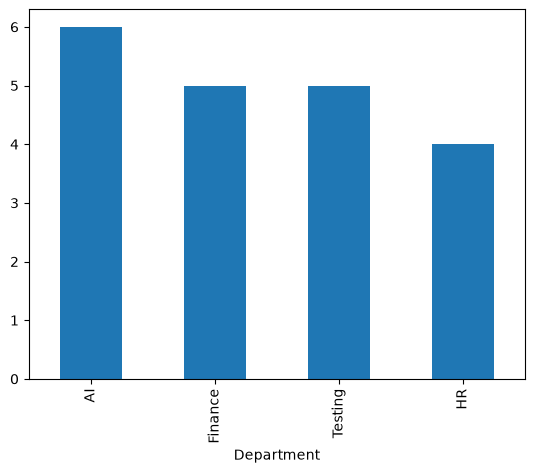

In [9]:
df['Department'].value_counts().plot(kind='bar')
plt.show()

## Q20

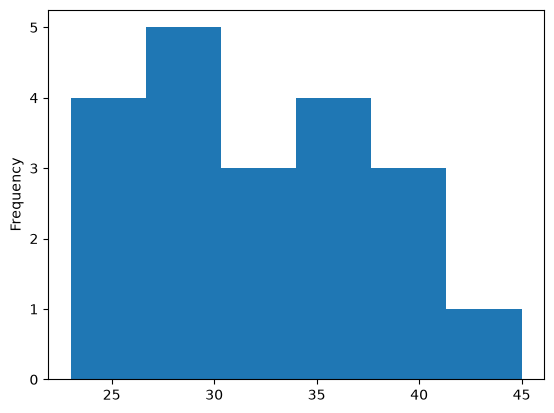

In [10]:
df['Age'].plot(kind='hist',bins=6)
plt.show()

## Q21

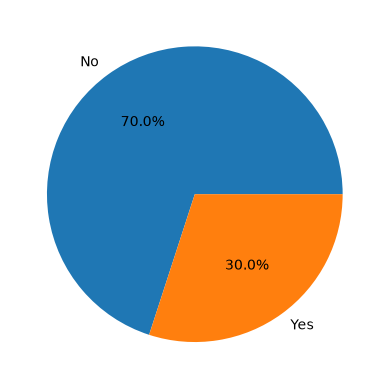

In [11]:
df['Left_Company'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.show()

## Q22

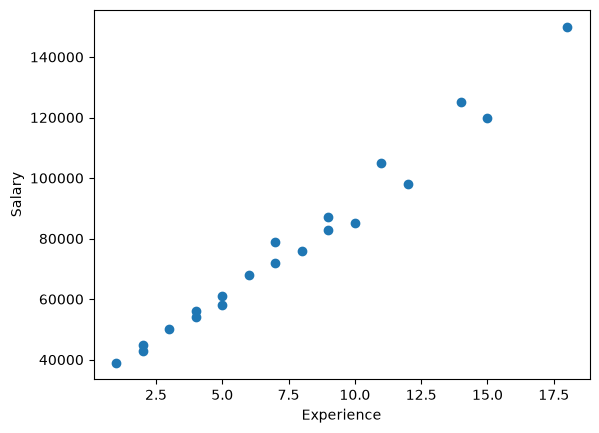

In [12]:
plt.scatter(df['Experience'],df['Salary'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

## Q23

In [ ]:
plt.boxplot(df['Salary'])
plt.show()

## Q24

In [ ]:
plt.plot(df['Monthly_Watch_Time'])
plt.show()

## Q25

In [ ]:
plt.plot(df['Experience'],df['Monthly_Sales'],'o-')
plt.show()

## Q26

In [ ]:
df[['Salary','Experience']].corr()

## Q27

In [ ]:
df[['Salary','Monthly_Sales']].corr()

## Q28

In [ ]:
df[['Training_Hours','Performance_Rating']].corr()

## Q29

In [ ]:
df.corr(numeric_only=True)['Salary'].sort_values(ascending=False)

## Q30

In [ ]:
df.corr(numeric_only=True)

## Q31

In [ ]:
df.sample(8,random_state=1)

## Q32

In [ ]:
df.groupby('Department',group_keys=False).apply(lambda x:x.sample(2,random_state=1))

## Q33

In [ ]:
df[df.Department=='AI']

## Q34

In [ ]:
df.iloc[::3]

## Q35

In [ ]:
(df.Left_Company=='Yes').mean()

## Q36

In [ ]:
(df.Department=='AI').mean()

## Q37

In [ ]:
((df.query('Performance_Rating<=3').Left_Company=='Yes').mean())

## Q38

In [ ]:
(df.Converted=='Yes').mean()

## Q39

In [ ]:
bcr=(df.Converted=='Yes').mean()
bcr*1.10

## Q40

In [ ]:
a=df[df.Work_Mode=='Office'].Monthly_Watch_Time
b=df[df.Work_Mode=='Hybrid'].Monthly_Watch_Time
print(a.mean(),b.mean())
print(ttest_ind(a,b,equal_var=False))

## Q41

In [ ]:
from scipy.stats import t
m=df.Salary.mean()
s=df.Salary.std(ddof=1)
n=len(df)
ci=t.interval(0.95,n-1,loc=m,scale=s/(n**0.5))
ci

## Q42

In [ ]:
a=df[df.Department=='AI'].Performance_Rating
b=df[df.Department=='Finance'].Performance_Rating
ttest_ind(a,b,equal_var=False)

## Q43

In [ ]:
df.assign(Z=zscore(df.Salary)).query('abs(Z)>2')

## Q44

In [ ]:
chi2_contingency(pd.crosstab(df.Department,df.Left_Company))

## Q45

In [ ]:
f_oneway(*(g.Monthly_Sales for _,g in df.groupby('Work_Mode')))

## Q46

In [ ]:
X=df[['Experience']]
y=df.Salary
m=LinearRegression().fit(X,y)
print(m.coef_[0],m.intercept_,r2_score(y,m.predict(X)))

## Q47

In [15]:
import numpy as np
a=df[df.Work_Mode=='Office'].Monthly_Watch_Time
b=df[df.Work_Mode=='Hybrid'].Monthly_Watch_Time
sp=np.sqrt(((len(a)-1)*a.var()+(len(b)-1)*b.var())/(len(a)+len(b)-2))
(b.mean()-a.mean())/sp

np.float64(1.3425483069093758)

## Q48

In [ ]:
med=[df.Training_Hours.sample(frac=1,replace=True).median() for _ in range(1000)]
np.percentile(med,[2.5,97.5])

## Q49

In [ ]:
q1,q3=df.Monthly_Sales.quantile([.25,.75])
iqr=q3-q1
f=df[(df.Monthly_Sales>=q1-1.5*iqr)&(df.Monthly_Sales<=q3+1.5*iqr)]
print(df.Monthly_Sales.mean(),f.Monthly_Sales.mean())

## Q50

In [ ]:
p=((df.Performance_Rating<=3)&(df.Fraud_Score>0.5)&(df.Left_Company=='Yes')).sum()/(((df.Performance_Rating<=3)&(df.Fraud_Score>0.5)).sum())
print(p)